In [1]:
# ==============================================================================
# 1. CÀI ĐẶT MÔI TRƯỜNG BACKTEST
# ==============================================================================
print("⏳ Đang cài đặt thư viện Backtest & QuantStats...")
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git -q
!pip install shimmy>=0.2.1 -q
!pip install quantstats -q
!pip install yfinance -q

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import yfinance as yf
import quantstats as qs
import zipfile

# Import các thuật toán để load model
from stable_baselines3 import DDPG, TD3, SAC, A2C, PPO
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.config import INDICATORS

print("✅ Cài đặt hoàn tất! Sẵn sàng Backtest.")

⏳ Đang cài đặt thư viện Backtest & QuantStats...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.7/108.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 43.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 41.3 MB/s eta 0:00

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/websockets/legacy/__init__.py:6: DeprecationWarning: websockets.legacy is deprecated; see https://websockets.readthedocs.io/en/stable/howto/upgrade.html for upgrade instructions
  warnings.warn(  # deprecated in 14.0 - 2024-11-09
/usr/local/lib/python3.12/dist-packages/jupyte

✅ Cài đặt hoàn tất! Sẵn sàng Backtest.


In [2]:
# ==============================================================================
# 2. GIẢI NÉN MODEL TỪ FILE ZIP
# ==============================================================================
zip_path = "all_5_models_safe.zip"

if os.path.exists(zip_path):
    print(f"📦 Đang giải nén '{zip_path}'...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("✅ Giải nén thành công! Các model đã nằm trong thư mục 'trained_models'.")
else:
    print("❌ LỖI: Không tìm thấy file 'all_5_models_safe.zip'. Hãy upload file này lên Colab ngay!")

📦 Đang giải nén 'all_5_models_safe.zip'...
✅ Giải nén thành công! Các model đã nằm trong thư mục 'trained_models'.


In [7]:
# ==============================================================================
# 3. CHUẨN BỊ DỮ LIỆU TEST (ĐÃ SỬA LỖI GIÁ = 0)
# ==============================================================================

# Đổi tên file này nếu bạn có file test riêng (vd: 'test_data.csv')
TEST_FILE = 'trade_data.csv'

if not os.path.exists(TEST_FILE):
    print(f"⚠️ Không thấy '{TEST_FILE}', hệ thống sẽ dùng tạm 'train_data.csv'...")
    if os.path.exists('train_data.csv'):
        TEST_FILE = 'train_data.csv'
        print("⚠️ Đang chạy In-Sample Test (Test trên dữ liệu đã học).")
    else:
        raise FileNotFoundError("❌ Bạn chưa upload file dữ liệu csv nào cả!")

# 1. Load Data
trade = pd.read_csv(TEST_FILE)

# --- BƯỚC SỬA LỖI QUAN TRỌNG ---
# Kiểm tra và loại bỏ các dòng có giá đóng cửa (close) <= 0 hoặc bị rỗng (NaN)
print(f"📉 Dữ liệu gốc: {trade.shape}")
trade = trade[trade['close'] > 0.0001] # Chỉ giữ lại giá > 0
trade = trade.dropna() # Xóa các dòng thiếu dữ liệu
print(f"📈 Dữ liệu sau khi làm sạch: {trade.shape}")
# -------------------------------

trade = trade.sort_values(['date', 'tic']).reset_index(drop=True)
trade.index = trade.date.factorize()[0]

print(f"⏳ Giai đoạn: {trade.date.min()} đến {trade.date.max()}")

# 2. Cấu hình Môi trường (Copy y hệt file Train)
stock_dimension = len(trade.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension

env_kwargs = {
    "hmax": 100, "initial_amount": 1000000,
    "num_stock_shares": [0]*stock_dimension,
    "buy_cost_pct": [0.001]*stock_dimension, "sell_cost_pct": [0.001]*stock_dimension,
    "state_space": state_space, "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS, "action_space": stock_dimension, "reward_scaling": 1e-4
}

# Tạo môi trường thực
e_trade_gym = StockTradingEnv(df = trade, turbulence_threshold = 70, **env_kwargs)
print("✅ Môi trường Test đã sẵn sàng (Đã loại bỏ giá 0)!")

📉 Dữ liệu gốc: (20104, 19)
📈 Dữ liệu sau khi làm sạch: (13832, 19)
⏳ Giai đoạn: 2024-01-02 đến 2025-12-18
✅ Môi trường Test đã sẵn sàng (Đã loại bỏ giá 0)!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
# ==============================================================================
# 4. HÀM CHẠY BACKTEST TỰ ĐỘNG (ĐÃ SỬA LỖI ATTRIBUTE ERROR)
# ==============================================================================
def predict_trades(model_name, model_class, model_path, env):
    """
    Hàm này load model và chạy thử trên môi trường test.
    Trả về: Chuỗi lợi nhuận hàng ngày (Daily Returns).
    """
    print(f"🤖 Đang chạy Backtest cho: {model_name}...")

    # 1. Load Model
    if not os.path.exists(model_path):
        if os.path.exists(model_path + ".zip"):
            model_path += ".zip"
        else:
            print(f"⚠️ LỖI: Không tìm thấy file model tại {model_path}")
            return None

    try:
        model = model_class.load(model_path)
    except Exception as e:
        print(f"❌ Lỗi khi load model {model_name}: {e}")
        return None

    # 2. Reset môi trường & Chạy
    obs, _ = env.reset()
    done = False
    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, rewards, done, truncated, info = env.step(action)
        if done or truncated:
            break

    # 3. Tính toán tài sản (SỬA LỖI TẠI ĐÂY)
    # Thay vì gọi hàm cũ bị lỗi, ta lấy dữ liệu trực tiếp từ memory của env
    try:
        # Lấy dữ liệu từ bộ nhớ của môi trường
        date_memory = env.date_memory
        asset_memory = env.asset_memory

        # Đảm bảo độ dài 2 mảng bằng nhau (đôi khi asset_memory có giá trị khởi tạo dư ra)
        min_len = min(len(date_memory), len(asset_memory))
        df_account = pd.DataFrame({
            'date': date_memory[:min_len],
            'account_value': asset_memory[:min_len]
        })
    except AttributeError:
        # Phòng trường hợp biến tên khác, thử cách dự phòng
        print(f"⚠️ Cảnh báo: Không truy cập được memory trực tiếp. Đang thử cách khác...")
        return None

    # Tính lợi nhuận % hàng ngày
    df_return = df_account.copy()
    df_return['daily_return'] = df_return['account_value'].pct_change(1)
    df_return['date'] = pd.to_datetime(df_return['date'])
    df_return.set_index('date', inplace=True)

    # Xóa dòng NaN đầu tiên và trả về kết quả
    return df_return['daily_return'].dropna()

print("✅ Đã khởi tạo lại bộ máy dự đoán (Fix lỗi FinRL update)!")

✅ Đã khởi tạo lại bộ máy dự đoán (Fix lỗi FinRL update)!


In [11]:
# ==============================================================================
# 5. THỰC HIỆN BACKTEST TOÀN BỘ
# ==============================================================================
results = {}

# Chạy lần lượt từng model
# Lưu ý: Đường dẫn phải khớp với cách file zip được giải nén
results['A2C']  = predict_trades("A2C",  A2C,  "trained_models/a2c/agent_a2c",   e_trade_gym)
results['PPO']  = predict_trades("PPO",  PPO,  "trained_models/ppo/agent_ppo",   e_trade_gym)
results['DDPG'] = predict_trades("DDPG", DDPG, "trained_models/ddpg/agent_ddpg", e_trade_gym)
results['TD3']  = predict_trades("TD3",  TD3,  "trained_models/td3/agent_td3",   e_trade_gym)
results['SAC']  = predict_trades("SAC",  SAC,  "trained_models/sac/agent_sac",   e_trade_gym)

print("\n🎉 Đã hoàn thành vòng chạy Backtest!")

🤖 Đang chạy Backtest cho: A2C...
🤖 Đang chạy Backtest cho: PPO...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🤖 Đang chạy Backtest cho: DDPG...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🤖 Đang chạy Backtest cho: TD3...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🤖 Đang chạy Backtest cho: SAC...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



🎉 Đã hoàn thành vòng chạy Backtest!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
# ==============================================================================
# 6. TẢI DỮ LIỆU BASELINE (DOW JONES)
# ==============================================================================
# Lấy ngày bắt đầu/kết thúc thực tế từ dữ liệu
start_date = trade['date'].min()
end_date = trade['date'].max()

print(f"📥 Đang tải chỉ số Dow Jones (^DJI) từ {start_date} đến {end_date}...")

# Tải dữ liệu
baseline_df = yf.download("^DJI", start=start_date, end=end_date, progress=False)

if len(baseline_df) > 0:
    # Tính lợi nhuận baseline
    baseline_returns = baseline_df['Close'].pct_change().dropna()
    baseline_returns.index = baseline_returns.index.tz_localize(None) # Fix lỗi múi giờ
    print("✅ Đã tải xong Baseline!")
else:
    print("⚠️ Không tải được Baseline. Kiểm tra lại kết nối mạng.")
    baseline_returns = None

📥 Đang tải chỉ số Dow Jones (^DJI) từ 2024-01-02 đến 2025-12-18...
✅ Đã tải xong Baseline!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



📊 BẢNG TỔNG SẮP CHI TIẾT:
MODEL      | LỢI NHUẬN    | SHARPE     | MAX DRAWDOWN    | WIN RATE  
---------------------------------------------------------------------------
TD3        | 22.89%       | 0.9233     | -8.16%          | 47.94%    
Dow Jones  | 26.97%       | 0.9228     | -16.37%         | 54.07%    
PPO        | 3.70%        | 0.8136     | -2.61%          | 47.33%    
DDPG       | 16.53%       | 0.7684     | -8.82%          | 46.91%    
SAC        | 13.00%       | 0.5858     | -11.68%         | 46.30%    
A2C        | 12.05%       | 0.5439     | -10.37%         | 46.30%    
📌 Đang vẽ biểu đồ, vui lòng chờ giây lát...



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


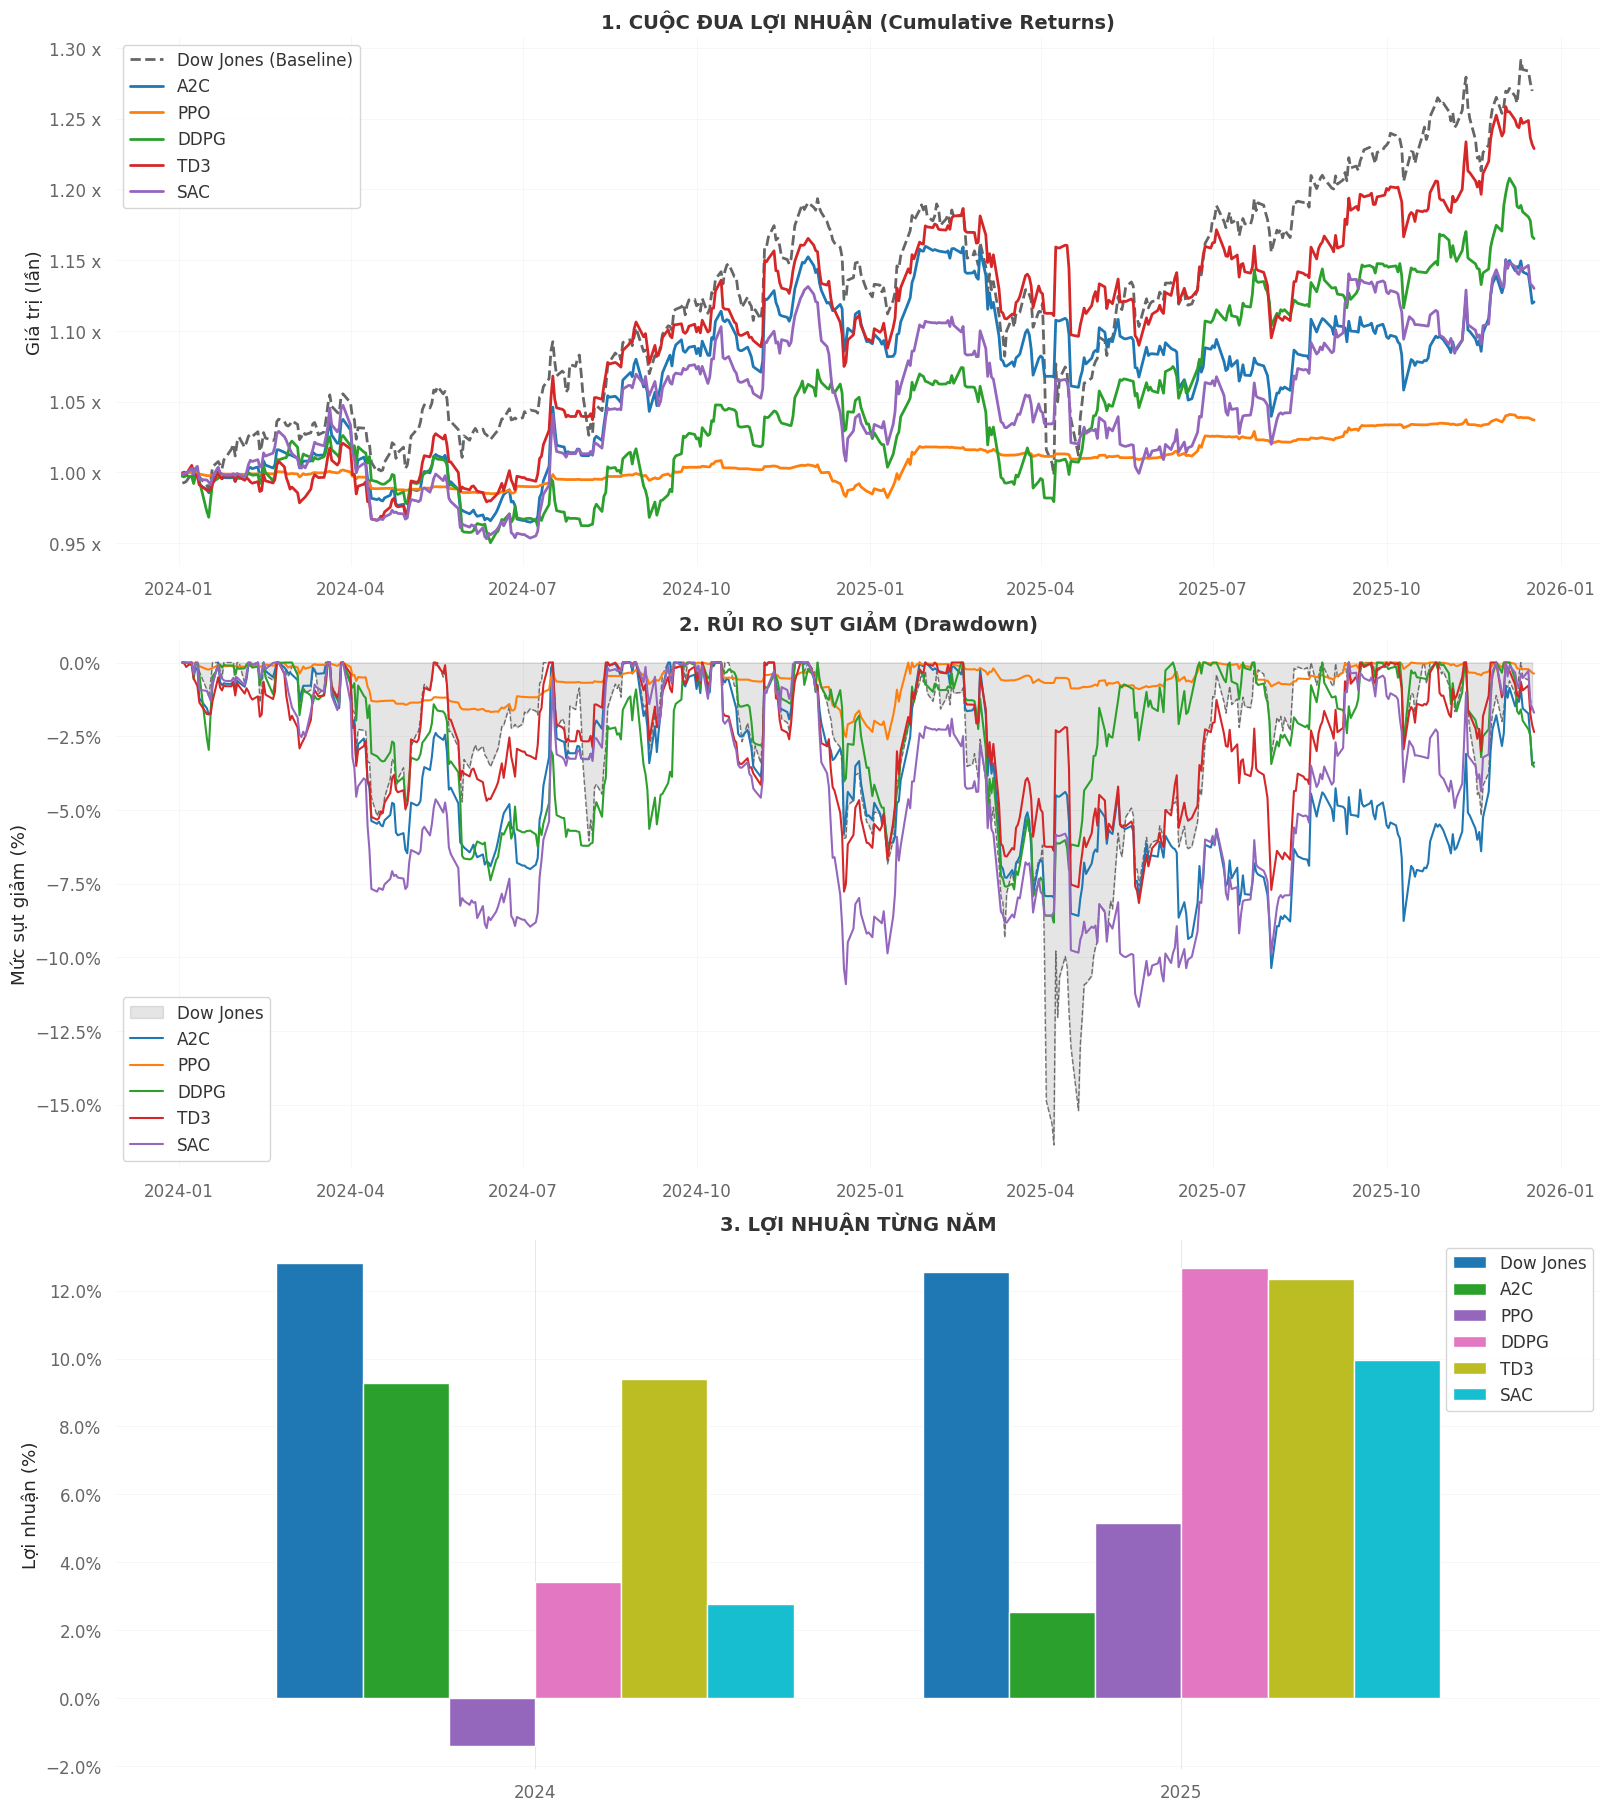

In [19]:
# ==============================================================================
# 7. VẼ BIỂU ĐỒ PHÂN TÍCH CHUYÊN SÂU (ĐÃ SỬA LỖI HIỂN THỊ)
# ==============================================================================
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import quantstats as qs
import pandas as pd

# --- BƯỚC 1: XỬ LÝ DỮ LIỆU ---
# Kiểm tra nếu Baseline là DataFrame (2 chiều) thì chuyển về Series (1 chiều)
if baseline_returns is not None:
    if isinstance(baseline_returns, pd.DataFrame):
        baseline_returns = baseline_returns.iloc[:, 0]

# Lọc ra các kết quả hợp lệ
valid_results = {k: v for k, v in results.items() if v is not None}
colors = {'A2C': '#1f77b4', 'PPO': '#ff7f0e', 'DDPG': '#2ca02c',
          'TD3': '#d62728', 'SAC': '#9467bd', 'Dow Jones': 'black'}

# --- BƯỚC 2: IN BẢNG KẾT QUẢ TRƯỚC (ĐỂ KHÔNG BỊ MẤT BIỂU ĐỒ) ---
print("\n📊 BẢNG TỔNG SẮP CHI TIẾT:")
print("=" * 75)
print(f"{'MODEL':<10} | {'LỢI NHUẬN':<12} | {'SHARPE':<10} | {'MAX DRAWDOWN':<15} | {'WIN RATE':<10}")
print("-" * 75)

metrics = []
# Thêm Baseline vào so sánh tạm thời để tính chỉ số
temp_results = valid_results.copy()
if baseline_returns is not None:
    temp_results['Dow Jones'] = baseline_returns

for name, returns in temp_results.items():
    if len(returns) > 0:
        # Ép kiểu về 1 chiều nếu cần
        if isinstance(returns, pd.DataFrame): returns = returns.iloc[:, 0]

        cum_r = (1 + returns).cumprod().iloc[-1] - 1
        sharpe = qs.stats.sharpe(returns)
        max_dd = qs.stats.max_drawdown(returns)
        win_rate = qs.stats.win_rate(returns)
        metrics.append((name, cum_r, sharpe, max_dd, win_rate))

# Sắp xếp theo Sharpe giảm dần
metrics.sort(key=lambda x: x[2], reverse=True)

for name, cum_r, sharpe, max_dd, win_rate in metrics:
    print(f"{name:<10} | {cum_r:<12.2%} | {sharpe:<10.4f} | {max_dd:<15.2%} | {win_rate:<10.2%}")
print("=" * 75)
print("📌 Đang vẽ biểu đồ, vui lòng chờ giây lát...\n")


# --- BƯỚC 3: VẼ BIỂU ĐỒ ---
# Tạo khung hình lớn: 3 biểu đồ (3 hàng, 1 cột)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 18), constrained_layout=True)

# BIỂU ĐỒ 1: TĂNG TRƯỞNG TÀI SẢN (CUMULATIVE RETURN)
if baseline_returns is not None:
    cum_base = (1 + baseline_returns).cumprod()
    ax1.plot(cum_base, label='Dow Jones (Baseline)', linestyle='--', color='black', linewidth=2, alpha=0.6)

for name, returns in valid_results.items():
    cum_ret = (1 + returns).cumprod()
    ax1.plot(cum_ret, label=name, color=colors.get(name, 'grey'), linewidth=2)

ax1.set_title('1. CUỘC ĐUA LỢI NHUẬN (Cumulative Returns)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Giá trị (lần)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f x'))

# BIỂU ĐỒ 2: ĐỘ SỤT GIẢM TÀI SẢN (UNDERWATER / DRAWDOWN)
def calculate_drawdown(returns):
    if isinstance(returns, pd.DataFrame): returns = returns.iloc[:, 0]
    cum_ret = (1 + returns).cumprod()
    rolling_max = cum_ret.cummax()
    drawdown = (cum_ret - rolling_max) / rolling_max
    return drawdown

if baseline_returns is not None:
    dd_base = calculate_drawdown(baseline_returns)
    ax2.fill_between(dd_base.index, dd_base, 0, label='Dow Jones', color='black', alpha=0.1)
    ax2.plot(dd_base, color='black', linestyle='--', linewidth=1, alpha=0.5)

for name, returns in valid_results.items():
    dd = calculate_drawdown(returns)
    ax2.plot(dd, label=name, color=colors.get(name, 'grey'), linewidth=1.5)

ax2.set_title('2. RỦI RO SỤT GIẢM (Drawdown)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Mức sụt giảm (%)')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# BIỂU ĐỒ 3: HIỆU SUẤT TỪNG NĂM
annual_data = {}
if baseline_returns is not None:
    annual_data['Dow Jones'] = baseline_returns.resample('YE').apply(lambda x: (1 + x).prod() - 1)

for name, returns in valid_results.items():
    annual_data[name] = returns.resample('YE').apply(lambda x: (1 + x).prod() - 1)

df_annual = pd.DataFrame(annual_data)
df_annual.index = df_annual.index.year
df_annual.plot(kind='bar', ax=ax3, width=0.8, colormap='tab10')

ax3.set_title('3. LỢI NHUẬN TỪNG NĂM', fontsize=14, fontweight='bold')
ax3.set_ylabel('Lợi nhuận (%)')
ax3.grid(True, axis='y', alpha=0.3)
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax3.legend(loc='upper right')
plt.xticks(rotation=0)

plt.show() # Lệnh này nằm cuối cùng để đảm bảo hình hiện ra

🕵️‍♀️ Đang trích xuất dữ liệu danh mục của TD3...
🔄 Đang chạy lại mô phỏng cho TD3 để lấy dữ liệu chi tiết...
🤖 Đang chạy Backtest cho: TD3...
📊 Đang vẽ biểu đồ phân bổ tài sản...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


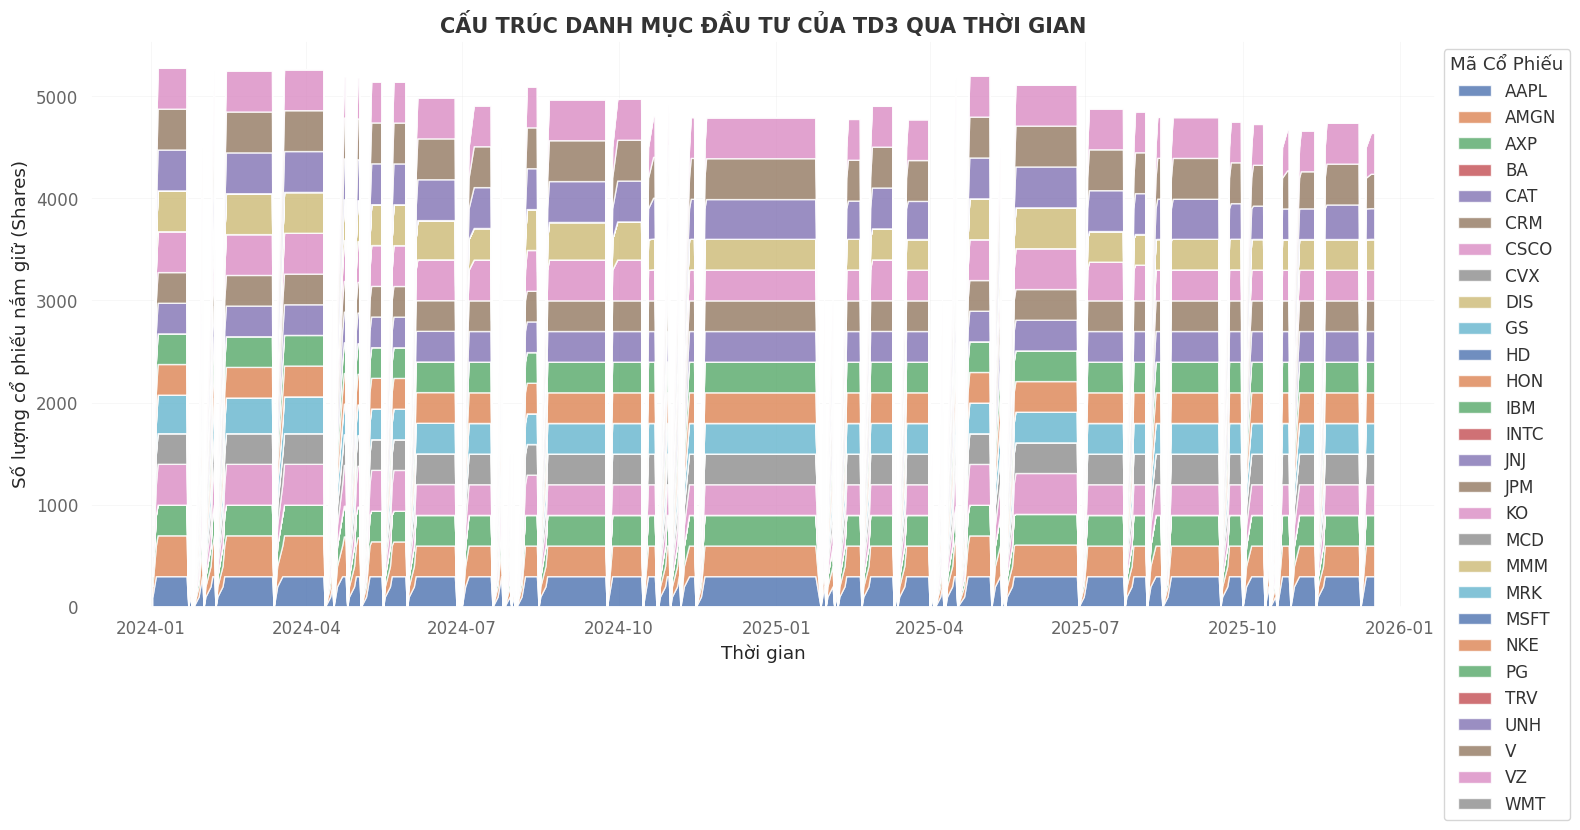


🔍 TOP 5 MÃ ĐƯỢC NẮM GIỮ NHIỀU NHẤT (Tại thời điểm cuối):
   - VZ: 400 cổ phiếu
   - V: 337 cổ phiếu
   - AAPL: 300 cổ phiếu
   - AMGN: 300 cổ phiếu
   - HON: 300 cổ phiếu


In [22]:
# ==============================================================================
# 8. SOI KỸ DANH MỤC ĐẦU TƯ (PORTFOLIO ALLOCATION) - ĐÃ FIX LỖI
# ==============================================================================
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. CHỌN MODEL ĐỂ SOI (Sửa tên model tại đây) ---
MODEL_NAME = "TD3"  # Bạn có thể đổi thành 'PPO', 'DDPG', 'A2C', 'SAC'
# ----------------------------------------------------

print(f"🕵️‍♀️ Đang trích xuất dữ liệu danh mục của {MODEL_NAME}...")

# Load model và lớp tương ứng
model_class_dict = {'A2C': A2C, 'PPO': PPO, 'DDPG': DDPG, 'TD3': TD3, 'SAC': SAC}
selected_model_class = model_class_dict.get(MODEL_NAME)

if selected_model_class:
    # Load đường dẫn model
    model_path = f"trained_models/{MODEL_NAME.lower()}/agent_{MODEL_NAME.lower()}"

    # Chạy lại dự đoán để lấy actions_memory mới nhất
    print(f"🔄 Đang chạy lại mô phỏng cho {MODEL_NAME} để lấy dữ liệu chi tiết...")
    predict_trades(MODEL_NAME, selected_model_class, model_path, e_trade_gym)

    # Lấy dữ liệu hành động (Mua/Bán)
    # actions_memory là list các array, mỗi array là số lượng mua/bán tại mỗi bước
    actions_df = pd.DataFrame(e_trade_gym.actions_memory)

    # --- SỬA LỖI TẠI ĐÂY ---
    # Thay vì lấy e_trade_gym.tic_list, ta lấy từ dữ liệu gốc 'trade'
    # trade['tic'].unique() trả về danh sách mã theo đúng thứ tự đã sort
    tic_list = trade['tic'].unique()

    # Đảm bảo số cột khớp nhau
    if len(tic_list) == actions_df.shape[1]:
        actions_df.columns = tic_list
    else:
        print(f"⚠️ Cảnh báo: Số lượng mã ({len(tic_list)}) không khớp số cột hành động ({actions_df.shape[1]}). Đang dùng tên mặc định.")
    # -----------------------

    # Lấy ngày tháng tương ứng
    date_col = e_trade_gym.date_memory[:len(actions_df)]
    actions_df.index = pd.to_datetime(date_col)

    # Tính số lượng nắm giữ (Cumulative Sum)
    holdings_df = actions_df.cumsum()

    # --- VẼ BIỂU ĐỒ ---
    print(f"📊 Đang vẽ biểu đồ phân bổ tài sản...")
    plt.figure(figsize=(16, 8))

    # Vẽ biểu đồ miền (Stackplot)
    plt.stackplot(holdings_df.index, holdings_df.T, labels=holdings_df.columns, alpha=0.8)

    plt.title(f'CẤU TRÚC DANH MỤC ĐẦU TƯ CỦA {MODEL_NAME} QUA THỜI GIAN', fontsize=15, fontweight='bold')
    plt.xlabel('Thời gian')
    plt.ylabel('Số lượng cổ phiếu nắm giữ (Shares)')

    # Chú thích nằm bên ngoài
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Mã Cổ Phiếu")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # In ra thống kê
    print("\n🔍 TOP 5 MÃ ĐƯỢC NẮM GIỮ NHIỀU NHẤT (Tại thời điểm cuối):")
    final_holdings = holdings_df.iloc[-1].sort_values(ascending=False).head(5)
    for tic, shares in final_holdings.items():
        print(f"   - {tic}: {int(shares)} cổ phiếu")

else:
    print(f"❌ Không tìm thấy model tên là {MODEL_NAME}. Hãy kiểm tra lại!")